In [156]:
import scanpy as sc
from scvi.external import MRVI
import matplotlib.pyplot as plt

Read data

In [173]:
adata = sc.read_h5ad("../../project_folder/data/pbmc68k_oversampled/pbmc68k_0.45.h5ad")

In [174]:
sample_key = "treatment"
sample_cov_keys = ["treatment"]

In [175]:
MRVI.setup_anndata(adata, sample_key=sample_key, layer="X_counts", backend="torch")

/tmp/ipykernel_1239613/3565248253.py:1: UserWarning: MRVI model is being setup with PyTorch backend
  MRVI.setup_anndata(adata, sample_key=sample_key, layer="X_counts", backend="torch")


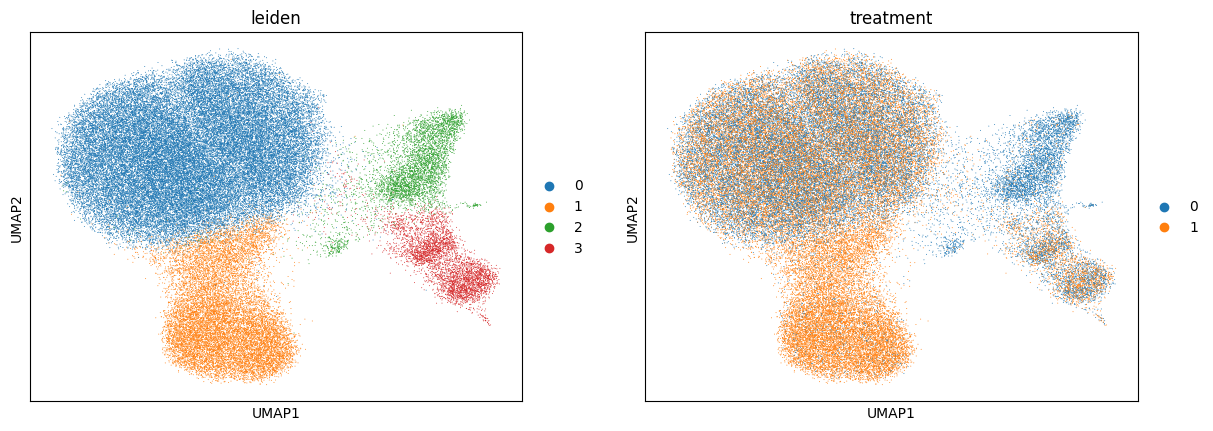

In [178]:
sc.pl.umap(adata, color=["leiden", "treatment"])

In [179]:
model = MRVI(adata, backend="torch")

/tmp/ipykernel_1239613/2973296923.py:1: UserWarning: backend parameter is ignored from version 1.4.1
  model = MRVI(adata, backend="torch")


In [180]:
model.module

TorchMRVAE(
  (px): DecoderZXAttention(
    (layer_norm): LayerNorm((30,), eps=1e-05, elementwise_affine=True)
    (layer_norm_batch_embed): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (batch_embedding): Embedding(1, 16)
    (attention_block): AttentionBlock(
      (query_proj): Linear(in_features=30, out_features=16, bias=False)
      (embed_dim_proj_query): Linear(in_features=1, out_features=8, bias=False)
      (embed_dim_proj_kv): Linear(in_features=1, out_features=8, bias=False)
      (kv_proj): Linear(in_features=16, out_features=16, bias=False)
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=8, out_features=8, bias=True)
      )
      (mlp_eps): MLP(
        (resnet_blocks): Sequential(
          (0): ResnetBlock(
            (fc1): Linear(in_features=128, out_features=128, bias=True)
            (layer_norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (fc2): Linear(in_features=128, out_f

In [181]:
model.train(max_epochs=100)

/home/icb/alessandro.palma/miniconda3/envs/scvi_env/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/icb/alessandro.palma/miniconda3/envs/scvi_ ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/icb/alessandro.palma/miniconda3/envs/scvi_env/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/icb/alessandro.palma/miniconda3/envs/scvi_ ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/icb/alessandro.palma/miniconda3/envs/scvi_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434:

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [182]:
# Get latent representations 
u = model.get_latent_representation()
adata.obsm["u"] = u
sc.pp.neighbors(adata, use_rep="u")
sc.tl.umap(adata)

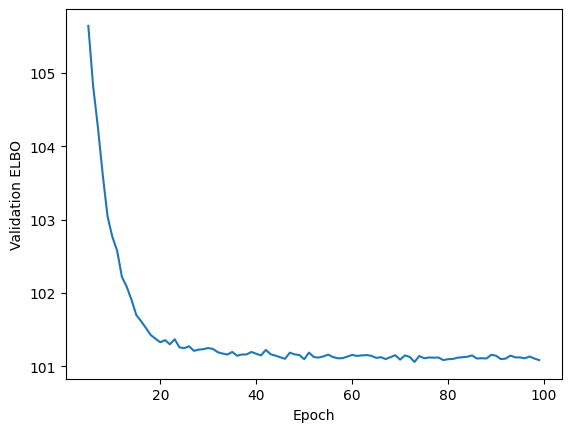

In [183]:
plt.plot(model.history["elbo_validation"].iloc[5:])
plt.xlabel("Epoch")
plt.ylabel("Validation ELBO")
plt.show()

In [184]:
dists = model.get_local_sample_distances(keep_cell=True,
                                             groupby="leiden", 
                                             batch_size=32)

100%|██████████| 2059/2059 [00:21<00:00, 97.70it/s] 


In [185]:
da_res = model.differential_abundance()
trt_log_probs = da_res.log_probs.loc[{"sample": 1}]
ctr_log_probs = da_res.log_probs.loc[{"sample": 0}]
log_prob_ratio = trt_log_probs - ctr_log_probs

100%|██████████| 2/2 [00:03<00:00,  1.97s/it]


In [186]:
adata.obs["log_ratio"] = log_prob_ratio 

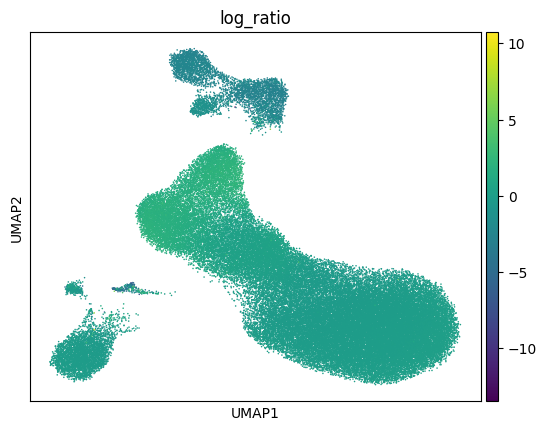

In [187]:
sc.pl.umap(adata, color="log_ratio", s=5)

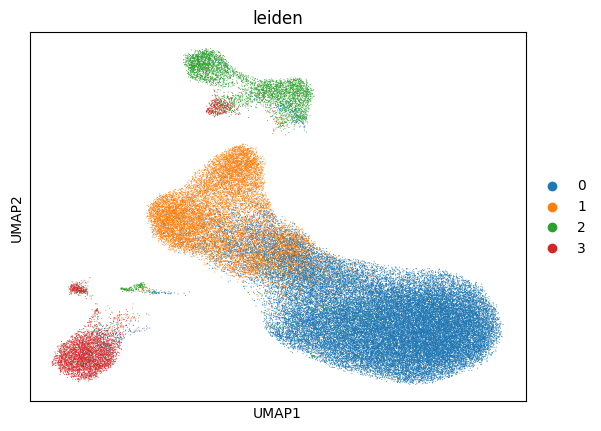

In [188]:
sc.pl.umap(adata, color="leiden")

(array([2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00,
        1.0000e+00, 1.0000e+00, 3.0000e+00, 2.0000e+00, 1.0000e+00,
        3.0000e+00, 2.0000e+00, 3.0000e+00, 5.0000e+00, 1.0000e+01,
        9.0000e+00, 1.1000e+01, 1.6000e+01, 2.0000e+01, 4.5000e+01,
        7.7000e+01, 5.0200e+02, 2.5070e+03, 7.5800e+02, 3.2800e+02,
        4.6500e+02, 8.8400e+02, 4.2082e+04, 6.9120e+03, 1.8260e+03,
        2.4850e+03, 5.8680e+03, 9.9400e+02, 2.9000e+01, 1.1000e+01,
        4.0000e+00, 2.0000e+00, 3.0000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-13.48572826, -13.00081539, -12.51590157, -12.03098869,
        -11.54607487, -11.06116199, -10.57624817, -10.0913353 ,
         -9.60642242,  -9.12150955,  -8.63659573,  -8.1516819 ,
         -7.66676903,  -7.18185568,  -6.69694281,  -6.21202946,
         -5.72711611,  -5.24220276,  -4.75728989,  -4.27237606

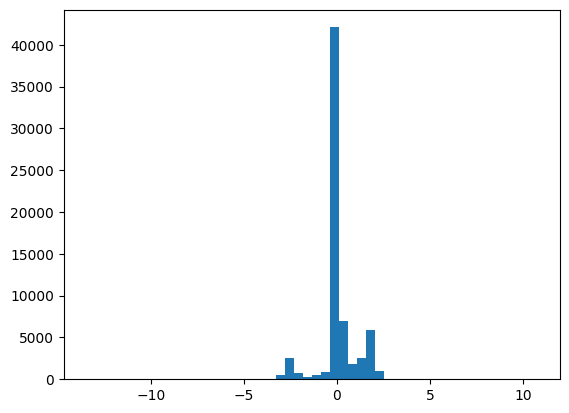

In [189]:
plt.hist(log_prob_ratio, 50)